In [1]:
import numpy as np
import fitsio
from astropy.table import Table,vstack,join,unique
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import scienceplots
plt.style.use(['science','grid','notebook'])
from matplotlib.colors import LogNorm
from astroquery.vizier import Vizier

from astropy.io import fits
from scipy.stats import truncnorm
from scipy.optimize import curve_fit

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
DR1_north= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_north_v1_sep_1.fits')[1].read())
DR1_south= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_south_v1_sep_1.fits')[1].read())
legacy_north = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_north_v1_sep_1.fits')[1].read())
legacy_south = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_south_v1_sep_1.fits')[1].read())
north = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v10_flux_w1.fits')[1].read())
south = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/south_cuts_v10_flux_w1.fits')[1].read())
north= north[north['DEC']>=32.275]
south = south[south['DEC']>-30]


In [6]:
coord_north =  SkyCoord(ra=north['RA']*u.deg, dec=north['DEC']*u.deg)
coord_south = SkyCoord(ra=south['RA']*u.deg, dec=south['DEC']*u.deg)
idx_south, idx_north, sep2d, _ = coord_north.search_around_sky(coord_south, 1.0*u.arcsec)

In [7]:
matched_north = north[idx_north]
matched_south = south[idx_south] 

In [8]:
len(north), len(south), len(matched_north), len(matched_south)

(141116, 337336, 6131, 6131)

In [9]:
def flux_to_mag(flux,trans):
    frac = flux/trans
    mag = np.full_like(frac, np.nan,dtype=float)
    valid = frac > 0
    frac = frac[valid]
    mag[valid] = 22.5 - 2.5 * np.log10(frac)
    return mag

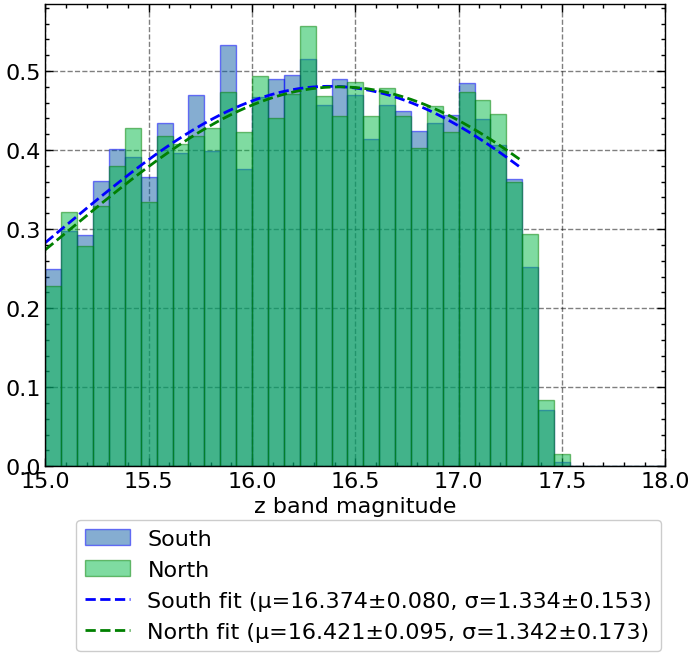

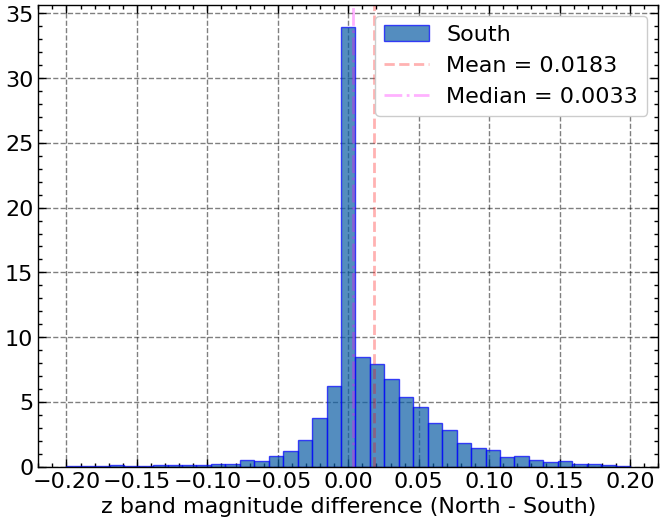

In [10]:
south_mag_z = flux_to_mag(matched_south['FLUX_Z'],matched_south['MW_TRANSMISSION_Z'])
north_mag_z = flux_to_mag(matched_north['FLUX_Z'],matched_north['MW_TRANSMISSION_Z'])
valid = np.isfinite(south_mag_z)
south_mag_z = south_mag_z[valid]
valid = np.isfinite(north_mag_z)
north_mag_z = north_mag_z[valid]
bins = np.linspace(15,18,40)
plt.hist(south_mag_z, bins=bins, alpha=0.5, label='South', density=True,edgecolor='b')
plt.hist(north_mag_z, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(15,18)
plt.legend()
plt.xlabel('z band magnitude')


def truncated_gaussian(x, mean, std, amp):
    a, b = (15 - mean) / std, (17.3- mean) / std
    return amp * truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Fit for south
hist_south, _ = np.histogram(south_mag_z, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
popt_south, pcov_south = curve_fit(truncated_gaussian, bin_centers, hist_south, p0=[15, 1, 1])

# Fit for north
hist_north, _ = np.histogram(north_mag_z, bins=bins, density=True)
popt_north, pcov_north = curve_fit(truncated_gaussian, bin_centers, hist_north, p0=[15, 1, 1])

# Calculate errors (standard deviations) from covariance matrix
perr_south = np.sqrt(np.diag(pcov_south))
perr_north = np.sqrt(np.diag(pcov_north))

# Plot the fits
x_fit = np.linspace(15, 17.3, 200)
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_south), 'b--', 
         label=f'South fit (μ={popt_south[0]:.3f}±{perr_south[0]:.3f}, σ={popt_south[1]:.3f}±{perr_south[1]:.3f})')
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_north), 'g--', 
         label=f'North fit (μ={popt_north[0]:.3f}±{perr_north[0]:.3f}, σ={popt_north[1]:.3f}±{perr_north[1]:.3f})')
plt.legend(loc = (0.05,-0.4))

plt.show()
bins = np.linspace(-0.2,0.2,40)
plt.hist(north_mag_z-south_mag_z, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.xlabel('z band magnitude difference (North - South)')
plt.axvline(np.mean(north_mag_z-south_mag_z), color='r', linestyle='--', label=f'Mean = {np.mean(north_mag_z-south_mag_z):3.4f}',alpha =0.3)
plt.axvline(np.median(north_mag_z-south_mag_z), color='magenta', linestyle='-.', label=f'Median = {np.median(north_mag_z-south_mag_z):.4f}',alpha=0.3)


plt.legend()

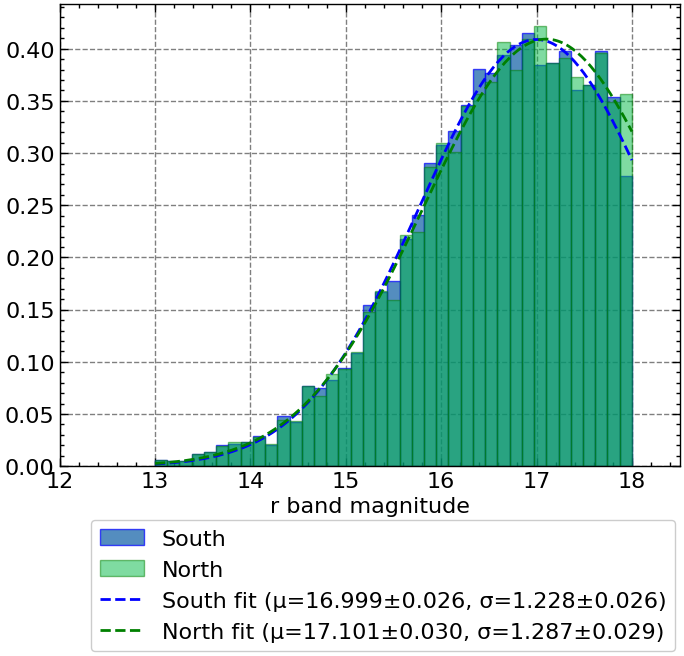

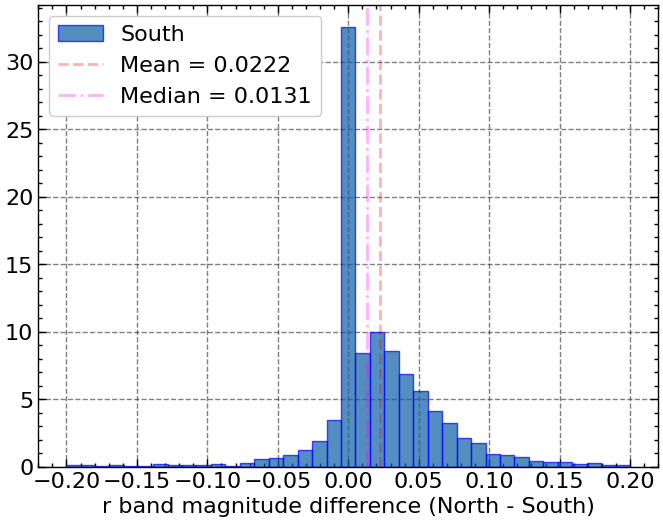

In [11]:


south_mag_r = flux_to_mag(matched_south['FLUX_R'],matched_south['MW_TRANSMISSION_R'])
north_mag_r = flux_to_mag(matched_north['FLUX_R'],matched_north['MW_TRANSMISSION_R'])
valid = np.isfinite(south_mag_r)
south_mag_r = south_mag_r[valid]
valid = np.isfinite(north_mag_r)
north_mag_r = north_mag_r[valid]
bins = np.linspace(13,18,40)
plt.hist(south_mag_r, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.hist(north_mag_r, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(12,18.5)
plt.legend()
plt.xlabel('r band magnitude')
def truncated_gaussian(x, mean, std, amp):
    a, b = (13 - mean) / std, (18 - mean) / std
    return amp * truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Fit for south
hist_south, _ = np.histogram(south_mag_r, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
popt_south, pcov_south = curve_fit(truncated_gaussian, bin_centers, hist_south, p0=[15, 1, 1])

# Fit for north
hist_north, _ = np.histogram(north_mag_r, bins=bins, density=True)
popt_north, pcov_north = curve_fit(truncated_gaussian, bin_centers, hist_north, p0=[15, 1, 1])

# Calculate errors (standard deviations) from covariance matrix
perr_south = np.sqrt(np.diag(pcov_south))
perr_north = np.sqrt(np.diag(pcov_north))

# Plot the fits
x_fit = np.linspace(13, 18, 200)
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_south), 'b--', 
         label=f'South fit (μ={popt_south[0]:.3f}±{perr_south[0]:.3f}, σ={popt_south[1]:.3f}±{perr_south[1]:.3f})')
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_north), 'g--', 
         label=f'North fit (μ={popt_north[0]:.3f}±{perr_north[0]:.3f}, σ={popt_north[1]:.3f}±{perr_north[1]:.3f})')
plt.legend(loc = (0.05,-0.4))

plt.show()
bins = np.linspace(-0.2,0.2,40)
plt.hist(north_mag_r-south_mag_r, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.xlabel('r band magnitude difference (North - South)')
plt.axvline(np.mean(north_mag_r-south_mag_r), color='r', linestyle='--', label=f'Mean = {np.mean(north_mag_r-south_mag_r):3.4f}',alpha =0.3)
plt.axvline(np.median(north_mag_r-south_mag_r), color='magenta', linestyle='-.', label=f'Median = {np.median(north_mag_r-south_mag_r):.4f}',alpha=0.3)


plt.legend()

In [16]:
17.096 - 16.994

0.10200000000000031

In [12]:
print(f"South r-band magnitude:")
print(f"  Mean: {np.mean(south_mag_r):.3f}")
print(f"  Median: {np.median(south_mag_r):.3f}")
print(f"  Std Dev: {np.std(south_mag_r):.3f}")
print(f"\nNorth r-band magnitude:")
print(f"  Mean: {np.mean(north_mag_r):.3f}")
print(f"  Median: {np.median(north_mag_r):.3f}")
print(f"  Std Dev: {np.std(north_mag_r):.3f}")

South r-band magnitude:
  Mean: 16.545
  Median: 16.672
  Std Dev: 0.951

North r-band magnitude:
  Mean: 16.567
  Median: 16.695
  Std Dev: 0.957


In [13]:
len(south_mag_r), len(north_mag_r)

(6131, 6131)

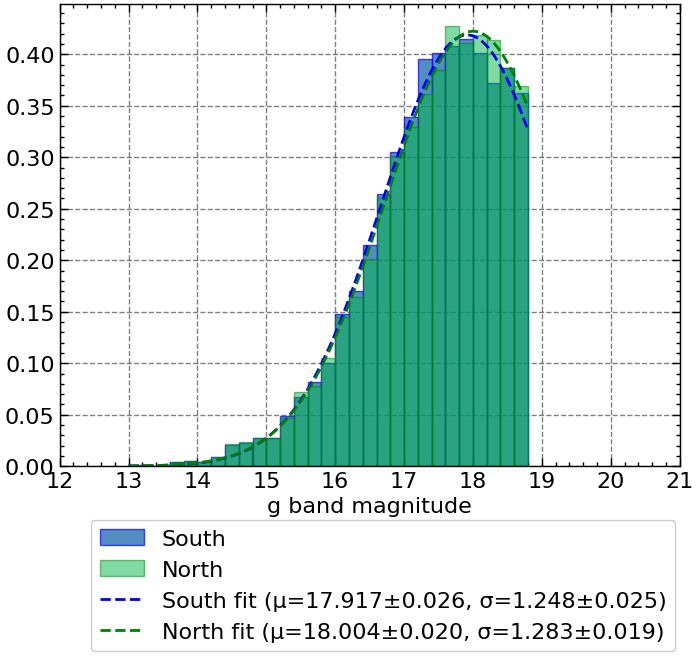

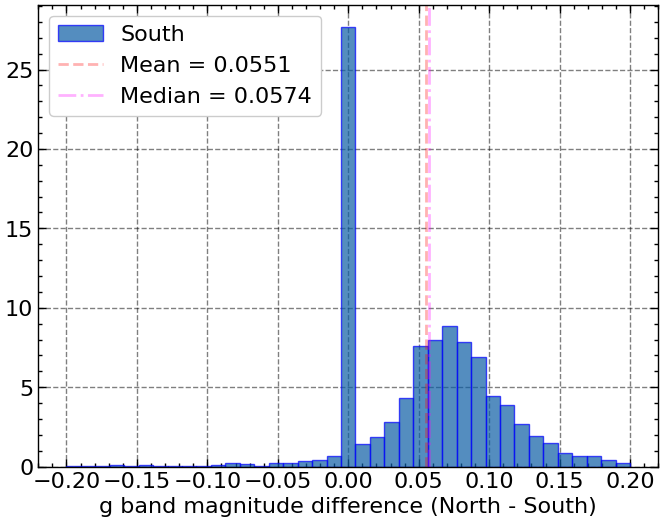

In [15]:

south_mag_g = flux_to_mag(matched_south['FLUX_G'],matched_south['MW_TRANSMISSION_G'])
north_mag_g = flux_to_mag(matched_north['FLUX_G'],matched_north['MW_TRANSMISSION_G'])
valid = np.isfinite(south_mag_g)
south_mag_g = south_mag_g[valid]
valid = np.isfinite(north_mag_g)
north_mag_g = north_mag_g[valid]
bins = np.linspace(13,18.8,30)
plt.hist(south_mag_g, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.hist(north_mag_g, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(12,21)
plt.legend()
plt.xlabel('g band magnitude')

def truncated_gaussian(x, mean, std, amp):
    a, b = (13 - mean) / std, (18.8 - mean) / std
    return amp * truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Fit for south
hist_south, _ = np.histogram(south_mag_g, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
popt_south, pcov_south = curve_fit(truncated_gaussian, bin_centers, hist_south, p0=[15, 1, 1])

# Fit for north
hist_north, _ = np.histogram(north_mag_g, bins=bins, density=True)
popt_north, pcov_north = curve_fit(truncated_gaussian, bin_centers, hist_north, p0=[15, 1, 1])

# Calculate errors (standard deviations) from covariance matrix
perr_south = np.sqrt(np.diag(pcov_south))
perr_north = np.sqrt(np.diag(pcov_north))

# Plot the fits
x_fit = np.linspace(13, 18.8, 200)
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_south), 'b--', 
         label=f'South fit (μ={popt_south[0]:.3f}±{perr_south[0]:.3f}, σ={popt_south[1]:.3f}±{perr_south[1]:.3f})')
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_north), 'g--', 
         label=f'North fit (μ={popt_north[0]:.3f}±{perr_north[0]:.3f}, σ={popt_north[1]:.3f}±{perr_north[1]:.3f})')
plt.legend(loc = (0.05,-0.4))

plt.show()
bins = np.linspace(-0.2,0.2,40)
plt.hist(north_mag_g-south_mag_g, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.xlabel('g band magnitude difference (North - South)')
plt.axvline(np.mean(north_mag_g-south_mag_g), color='r', linestyle='--', label=f'Mean = {np.mean(north_mag_g-south_mag_g):.4f}',alpha =0.3)
plt.axvline(np.median(north_mag_g-south_mag_g), color='magenta', linestyle='-.', label=f'Median = {np.median(north_mag_g-south_mag_g):.4f}',alpha=0.3)


plt.legend()

(0.012083045973594572, 0.015)

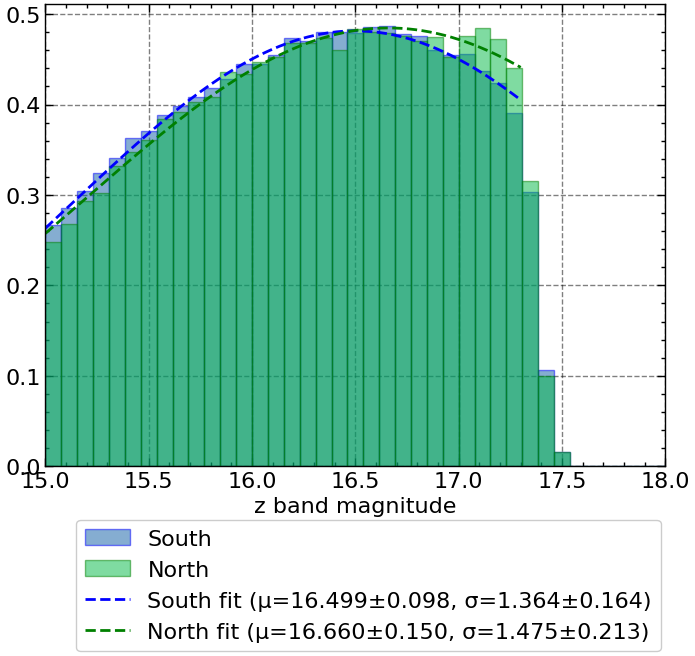

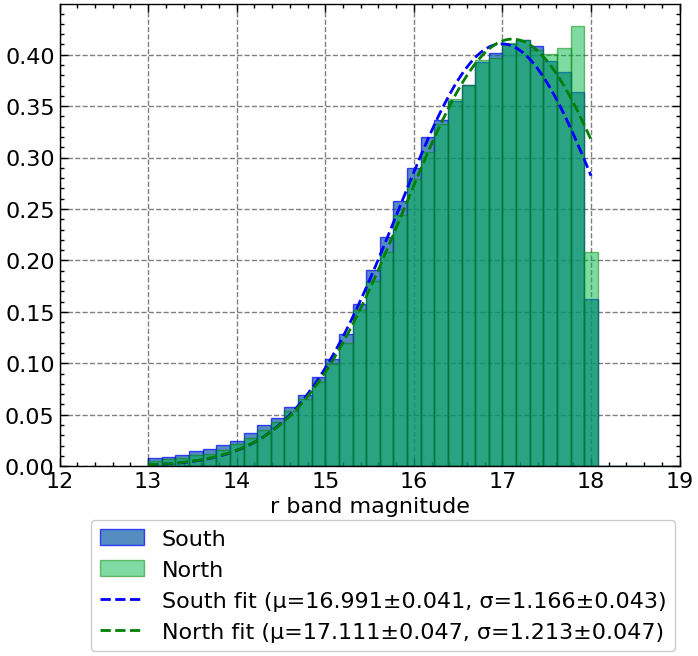

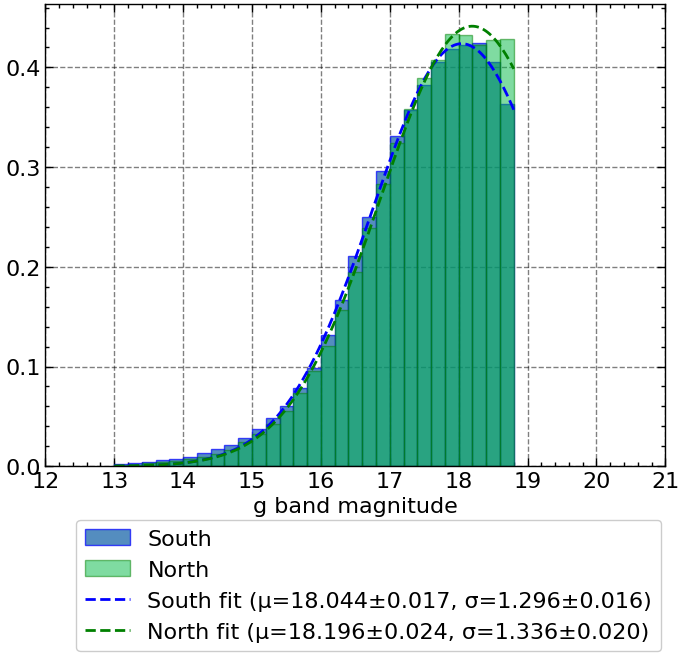

In [17]:
south_mag_z = flux_to_mag(south['FLUX_Z'],south['MW_TRANSMISSION_Z'])
north_mag_z = flux_to_mag(north['FLUX_Z'],north['MW_TRANSMISSION_Z'])
valid = np.isfinite(south_mag_z)
south_mag_z = south_mag_z[valid]
valid = np.isfinite(north_mag_z)
north_mag_z = north_mag_z[valid]
bins = np.linspace(15,18,40)
plt.hist(south_mag_z, bins=bins, alpha=0.5, label='South', density=True,edgecolor='b')
plt.hist(north_mag_z, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(15,18)
plt.legend()
plt.xlabel('z band magnitude')


def truncated_gaussian(x, mean, std, amp):
    a, b = (15 - mean) / std, (17.3- mean) / std
    return amp * truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Fit for south
hist_south, _ = np.histogram(south_mag_z, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
popt_south, pcov_south = curve_fit(truncated_gaussian, bin_centers, hist_south, p0=[15, 1, 1])

# Fit for north
hist_north, _ = np.histogram(north_mag_z, bins=bins, density=True)
popt_north, pcov_north = curve_fit(truncated_gaussian, bin_centers, hist_north, p0=[15, 1, 1])

# Calculate errors (standard deviations) from covariance matrix
perr_south = np.sqrt(np.diag(pcov_south))
perr_north = np.sqrt(np.diag(pcov_north))

# Plot the fits
x_fit = np.linspace(15, 17.3, 200)
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_south), 'b--', 
         label=f'South fit (μ={popt_south[0]:.3f}±{perr_south[0]:.3f}, σ={popt_south[1]:.3f}±{perr_south[1]:.3f})')
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_north), 'g--', 
         label=f'North fit (μ={popt_north[0]:.3f}±{perr_north[0]:.3f}, σ={popt_north[1]:.3f}±{perr_north[1]:.3f})')
plt.legend(loc = (0.05,-0.4))

plt.show()




south_mag_r = flux_to_mag(south['FLUX_R'],south['MW_TRANSMISSION_R'])
north_mag_r = flux_to_mag(north['FLUX_R'],north['MW_TRANSMISSION_R'])
valid = np.isfinite(south_mag_r)
south_mag_r = south_mag_r[valid]
valid = np.isfinite(north_mag_r)
north_mag_r = north_mag_r[valid]
bins = np.linspace(13,19,40)
plt.hist(south_mag_r, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.hist(north_mag_r, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(12,19)
plt.legend()
plt.xlabel('r band magnitude')
def truncated_gaussian(x, mean, std, amp):
    a, b = (13 - mean) / std, (18 - mean) / std
    return amp * truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Fit for south
hist_south, _ = np.histogram(south_mag_r, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
popt_south, pcov_south = curve_fit(truncated_gaussian, bin_centers, hist_south, p0=[15, 1, 1])

# Fit for north
hist_north, _ = np.histogram(north_mag_r, bins=bins, density=True)
popt_north, pcov_north = curve_fit(truncated_gaussian, bin_centers, hist_north, p0=[15, 1, 1])

# Calculate errors (standard deviations) from covariance matrix
perr_south = np.sqrt(np.diag(pcov_south))
perr_north = np.sqrt(np.diag(pcov_north))

# Plot the fits
x_fit = np.linspace(13, 18, 200)
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_south), 'b--', 
         label=f'South fit (μ={popt_south[0]:.3f}±{perr_south[0]:.3f}, σ={popt_south[1]:.3f}±{perr_south[1]:.3f})')
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_north), 'g--', 
         label=f'North fit (μ={popt_north[0]:.3f}±{perr_north[0]:.3f}, σ={popt_north[1]:.3f}±{perr_north[1]:.3f})')
plt.legend(loc = (0.05,-0.4))

plt.show()



south_mag_g = flux_to_mag(south['FLUX_G'],south['MW_TRANSMISSION_G'])
north_mag_g = flux_to_mag(north['FLUX_G'],north['MW_TRANSMISSION_G'])
valid = np.isfinite(south_mag_g)
south_mag_g = south_mag_g[valid]
valid = np.isfinite(north_mag_g)
north_mag_g = north_mag_g[valid]
bins = np.linspace(13,18.8,30)
plt.hist(south_mag_g, bins=bins, alpha=0.7, label='South', density=True,edgecolor='b')
plt.hist(north_mag_g, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(12,21)
plt.legend()
plt.xlabel('g band magnitude')

def truncated_gaussian(x, mean, std, amp):
    a, b = (13 - mean) / std, (18.8 - mean) / std
    return amp * truncnorm.pdf(x, a, b, loc=mean, scale=std)

# Fit for south
hist_south, _ = np.histogram(south_mag_g, bins=bins, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
popt_south, pcov_south = curve_fit(truncated_gaussian, bin_centers, hist_south, p0=[15, 1, 1])

# Fit for north
hist_north, _ = np.histogram(north_mag_g, bins=bins, density=True)
popt_north, pcov_north = curve_fit(truncated_gaussian, bin_centers, hist_north, p0=[15, 1, 1])

# Calculate errors (standard deviations) from covariance matrix
perr_south = np.sqrt(np.diag(pcov_south))
perr_north = np.sqrt(np.diag(pcov_north))

# Plot the fits
x_fit = np.linspace(13, 18.8, 200)
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_south), 'b--', 
         label=f'South fit (μ={popt_south[0]:.3f}±{perr_south[0]:.3f}, σ={popt_south[1]:.3f}±{perr_south[1]:.3f})')
plt.plot(x_fit, truncated_gaussian(x_fit, *popt_north), 'g--', 
         label=f'North fit (μ={popt_north[0]:.3f}±{perr_north[0]:.3f}, σ={popt_north[1]:.3f}±{perr_north[1]:.3f})')
plt.legend(loc = (0.05,-0.4))

plt.show()

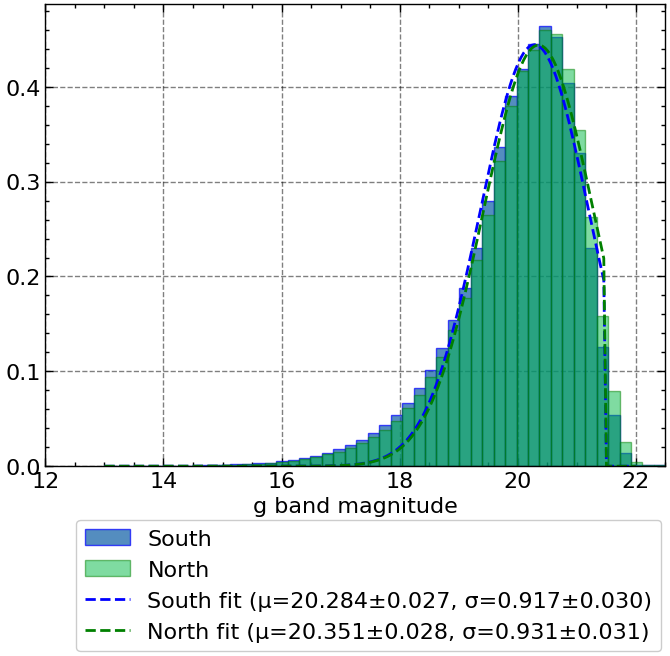

In [14]:
south_FP

BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_Z,FRACFLUX_G,FRACFLUX_R,FRACFLUX_Z,FRACMASKED_G,FRACMASKED_R,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_Z,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,SHAPE_R,SHAPE_E1,SHAPE_E2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,GAIA_PHOT_G_MEAN_MAG,MASKBITS,SERSIC,Z_PHOT_MEAN,Z_PHOT_MEDIAN,Z_PHOT_L95,Z_SPEC,SURVEY
int32,str8,int32,str3,float64,float64,float32[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,str10
328953,0063m002,88,SER,6.2504083186842445,-0.17019602166637282,109878.51 .. 203229.31,0.024569035,8.819468,23.083408,45.022522,51.045822,37.454506,42.254463,-285.98874,419.896,218.18933,25.090609,1.8468838,0.45245743,0.0006066459,0.9298525,0.95218915,0.97296846,0.99584496,0.9974462,0.9994548,0.9997941,7,7,6,0.016095262,0.008447226,0.013315171,0.006373092,0.0056602005,0.010138358,0.9975941,0.9979349,0.85507536,1.6458902,1.2127444,1.1019875,2580.5635,2320.3704,267.08746,1.7494427,0.1095856,-0.118353285,1.6241679,4.250974,8.291219,0.0,0,1.2758719,0.30236816,0.30089644,0.24855494,-99.0,
328953,0063m002,390,REX,6.258098548372631,-0.23824183188566184,330999.6 .. 0.0,0.023528399,11.54379,29.827127,57.800953,77.28176,63.441906,-86.03602,9697.131,474.71777,351.60413,36.389442,1.7998086,0.4749719,0.0007183991,0.93272126,0.954167,0.97409844,0.99602056,0.99755424,0.99947786,0.9998028,6,8,5,0.022836048,0.013068842,0.010490431,0.00069714815,0.0005321171,0.00089859974,0.7235279,0.8888899,0.714286,1.6787491,1.2258912,1.2281996,2068.5398,2640.2253,202.58287,1.0103832,0.0,0.0,3.212681,8.301004,16.086227,0.0,0,1.0,0.2941114,0.2962605,0.24198487,-99.0,
328953,0063m002,529,SER,6.261985808130063,-0.31959206439278426,172740.0 .. 253915.47,0.022788327,6.394104,16.084398,31.334341,41.051037,32.13815,162.68115,-5057.6694,895.5173,613.82465,59.596733,2.1028898,0.4787021,0.00066162786,0.9347669,0.9555762,0.9749028,0.9961455,0.9976311,0.9994943,0.999809,9,10,7,0.012219339,0.0059814863,0.0016275885,0.0035022656,0.002655376,0.021678915,0.9992636,0.9994069,0.9991451,1.6815984,1.2551651,1.1428573,2951.7573,3178.4312,284.91266,1.1605833,0.31873846,-0.017381653,2.105483,5.2963524,10.317931,0.0,0,1.2740772,0.28417578,0.2846828,0.20375149,-99.0,
328953,0063m002,590,SER,6.26362716189572,-0.1499482513838886,0.0 .. 0.0,0.025070697,300.60703,652.61847,1180.8732,903.17255,548.6876,728.8275,1120.421,40.857754,21.23781,3.4821491,0.27013958,0.1126859,0.00032401708,0.92847264,0.9512371,0.9724242,0.99576026,0.99739414,0.99944365,0.9997899,8,8,6,0.9471645,0.024401104,0.28148246,0.041056655,0.040694147,0.040398907,0.7978986,0.8893565,0.74753237,1.6516525,1.2726942,1.1351776,2703.4307,2395.7075,252.55737,5.2347727,0.052645862,-0.16757756,27.003803,58.625313,106.07891,0.0,4096,3.3263562,0.06297468,0.06403214,0.044679843,0.06289299,SDSS
328953,0063m002,726,SER,6.267476465634203,-0.19282674978856018,257175.27 .. 305201.7,0.024228787,7.503048,24.595167,49.74042,50.479923,33.50776,234.01585,-12670.231,554.9419,302.2417,36.93708,1.7833464,0.42993835,0.00052236323,0.9307895,0.9528354,0.97333777,0.99590236,0.9974815,0.99946237,0.9997969,8,8,6,0.020730967,0.0052470067,0.0036185207,0.040068448,0.03795765,0.04061172,0.88975316,0.9899004,0.8504254,1.6528164,1.2672787,1.1328667,2707.115,2409.367,251.81363,1.3427255,0.0221261,0.044036157,2.3924205,7.8424106,15.860223,0.0,0,6.0,0.22844422,0.22862895,0.20105736,

Text(0.5, 0, 'z band magnitude')

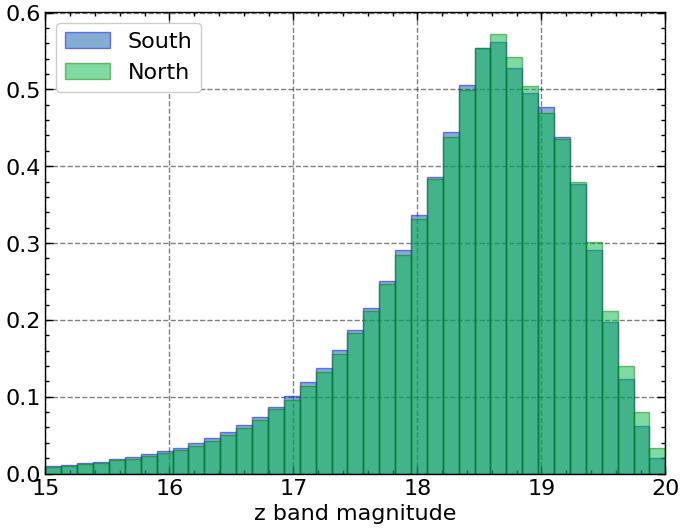

In [12]:
south_mag_FP_Z = flux_to_mag(south_FP['FLUX_Z'],south_FP['MW_TRANSMISSION_Z'])
north_mag_FP_Z = flux_to_mag(north_FP['FLUX_Z'],north_FP['MW_TRANSMISSION_Z'])
valid = np.isfinite(south_mag_FP_Z)
south_mag_FP_Z = south_mag_FP_Z[valid]
valid = np.isfinite(north_mag_FP_Z)
north_mag_FP_Z = north_mag_FP_Z[valid]
bins = np.linspace(15,20,40)
plt.hist(south_mag_FP_Z, bins=bins, alpha=0.5, label='South', density=True,edgecolor='b')
plt.hist(north_mag_FP_Z, bins=bins, alpha=0.5, label='North', density=True,edgecolor='g')
plt.xlim(15,20)
plt.legend()
plt.xlabel('z band magnitude')


In [18]:
south_mag_g = flux_to_mag(matched_south['FLUX_G'],matched_south['MW_TRANSMISSION_G'])
north_mag_g = flux_to_mag(matched_north['FLUX_G'],matched_north['MW_TRANSMISSION_G'])
valid = np.isfinite(south_mag_g)
south_mag_g = south_mag_g[valid]
valid = np.isfinite(north_mag_g)
north_mag_g = north_mag_g[valid]

In [ ]:
# Calculate angular separation between matched_south and matched_north
coord_matched_south = SkyCoord(ra=matched_south['RA']*u.deg, dec=matched_south['DEC']*u.deg)
coord_matched_north = SkyCoord(ra=matched_north['RA']*u.deg, dec=matched_north['DEC']*u.deg)

# Calculate separation
angular_sep = coord_matched_south.separation(coord_matched_north)

# Convert to arcseconds for better readability
angular_sep_arcsec = angular_sep.to(u.arcsec)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(angular_sep_arcsec.value, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Angular Separation (arcsec)')
plt.ylabel('Frequency')
plt.title('Angular Separation between Matched South and North')
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics
print(f"Mean angular separation: {np.mean(angular_sep_arcsec.value):.6f} arcsec")
print(f"Median angular separation: {np.median(angular_sep_arcsec.value):.6f} arcsec")
print(f"Std Dev: {np.std(angular_sep_arcsec.value):.6f} arcsec")
print(f"Max separation: {np.max(angular_sep_arcsec.value):.6f} arcsec")
print(f"Min separation: {np.min(angular_sep_arcsec.value):.6f} arcsec")